Objective:

The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.

Dataset:

1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.

2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.

3.	FM - May indicate "Fetal Movements" detected by the monitor.

4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.

5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.

6.	DS - May represent "Decelerations Short" or decelerations of brief duration.

7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.

8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.

9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.

10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.

11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.

Tools and Libraries:

●	Python programming language

●	Data manipulation libraries

●	Data visualization libraries (Matplotlib and Seaborn in Python)

●	Jupyter Notebook for documenting your analysis

Tasks:

1.	Data Cleaning and Preparation:

●	Load the dataset into a data frame or equivalent data structure.

●	Handle missing values appropriately (e.g., imputation, deletion).

●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

●	Detect and treat outliers if necessary.

2.	Statistical Summary:

●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).

●	Highlight any interesting findings from this summary.

3.	Data Visualization:

●	Create histograms or boxplots to visualize the distributions of various numerical variables.

●	Use bar charts or pie charts to display the frequency of categories for categorical variables.

●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

4.	Pattern Recognition and Insights:

●	Identify any correlations between variables and discuss their potential implications.

●	Look for trends or patterns over time if temporal data is available.

5.	Conclusion:

●	Summarize the key insights and patterns discovered through your exploratory analysis.

●	Discuss how these findings could impact decision-making or further analyses.
Deliverables:

●	A detailed Jupyter Notebook file containing the code, visualizations, and explanations for each step of your analysis.

●	A brief report summarizing your findings, insights, and any recommendations for further analysis or actions based on the data.


### *   Dataset cleaning and preparation

In [60]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [61]:
df = pd.read_csv('Cardiotocographic.csv')

In [62]:
df.head(8)

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,73.0,0.5,43.0,2.4,64.000000,0.999926,2.000000
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.000000,17.0,2.1,0.0,10.4,130.000000,0.000000,1.000000
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.000000,16.0,2.1,0.0,13.4,130.000000,0.000000,1.000000
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.000000,16.0,2.4,0.0,23.0,117.000000,1.000000,1.000000
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.000000,16.0,2.4,0.0,19.9,117.000000,1.000000,1.000000
5,134.000000,0.001116,0.0,0.010493,0.009444,0.0,0.002099,26.0,5.9,0.0,0.0,150.000000,0.000000,3.000000
6,134.000000,0.001403,0.0,0.012623,0.008415,0.0,0.002805,29.0,6.3,0.0,0.0,150.000000,0.000000,-1.025988
7,122.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,83.0,0.5,6.0,15.6,69.920261,1.000000,3.000000


In [63]:
df.shape

(2126, 14)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [65]:
#finding total null values in the dataset
df.isnull().sum()


,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [66]:
"""for numerical columns we fill the missing values with mean value since upon further there are two categorical columns 'Tendency' and 'NSP'
so we drop these two columns while we are working with numerical columns only"""

numerical_columns = df.select_dtypes(include = np.number).columns.drop(['NSP', 'Tendency'])
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

In [67]:
#check again for null values in numerical columns and cross checking whether the above code has affected the categorical columns
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [68]:
"""The above result shows no missing values in numerical columns and 21 for each categorical columns
Since NSP is a label we cannot guess labels hence we have to drop the rows with missing values in NSP column"""

#dropping rows with missing NSP values
df = df.dropna(subset=['NSP'])



In [69]:
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [70]:
#checking for inconsistenties in data types
df.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [71]:
#detection of outliers using IQR
Q1 = df[numerical_columns].quantile(0.25)       #first quartile (25 pertentile)
Q3 = df[numerical_columns].quantile(0.75)       #third quartile (75 percentile)
IQR = Q3 - Q1       #inter quartile range


In [72]:
outliers = (
    (df[numerical_columns] < (Q1 - 1.5 * IQR)) |        #lower bound check
    (df[numerical_columns] > (Q3 + 1.5 * IQR))          #upper bound check
).sum()
print("Outliers count per column:")
outliers

Outliers count per column:


,0
LB,10
AC,39
FM,343
UC,13
DL,124
DS,120
DP,284
ASTV,10
MSTV,78
ALTV,317


In [73]:
#cap outliers since it keeps all data and reduces the extreme influence
#calculating lower n uppwe bound for each column

for col in numerical_columns:
  lower = Q1[col] - 1.5 * IQR[col]
  upper = Q1[col] + 1.5 * IQR[col]
  df[col] = np.clip(df[col], lower, upper)   #clip values outside the lower n upper bounds to the nearest limit


### *   Statistical Summary:


In [74]:
#generate statistical summary for each column

summary = df.describe().T    #transpose to make each row represent a column
summary['median'] = df.median()
summary['IQR'] = Q3 - Q1

print('\nStatistical Summary')
summary


Statistical Summary


,count,mean,std,min,25%,50%,75%,max,median,IQR
LB,2105.0,132.934737,9.315958,105.000000,126.000000,133.000000,140.000000,147.000000,133.000000,14.000000
AC,2105.0,0.002844,0.003209,-0.008475,0.000000,0.001631,0.005650,0.008475,0.001631,0.005650
FM,2105.0,0.001100,0.001636,-0.003831,0.000000,0.000000,0.002554,0.003831,0.000000,0.002554
UC,2105.0,0.004272,0.002837,-0.005209,0.001838,0.004484,0.006536,0.008885,0.004484,0.004698
DL,2105.0,0.001438,0.002011,-0.004934,0.000000,0.000000,0.003289,0.004934,0.000000,0.003289
DS,2105.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,2105.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASTV,2105.0,46.749792,17.168247,-11.500000,32.000000,49.000000,61.000000,75.500000,49.000000,29.000000
MSTV,2105.0,1.222315,0.628456,-0.800000,0.700000,1.200000,1.700000,2.200000,1.200000,1.000000
ALTV,2105.0,4.814187,6.863435,-16.500000,0.000000,0.000000,11.000000,16.500000,0.000000,11.000000


### *   Data Visualization:

<Figure size 3000x3000 with 0 Axes>

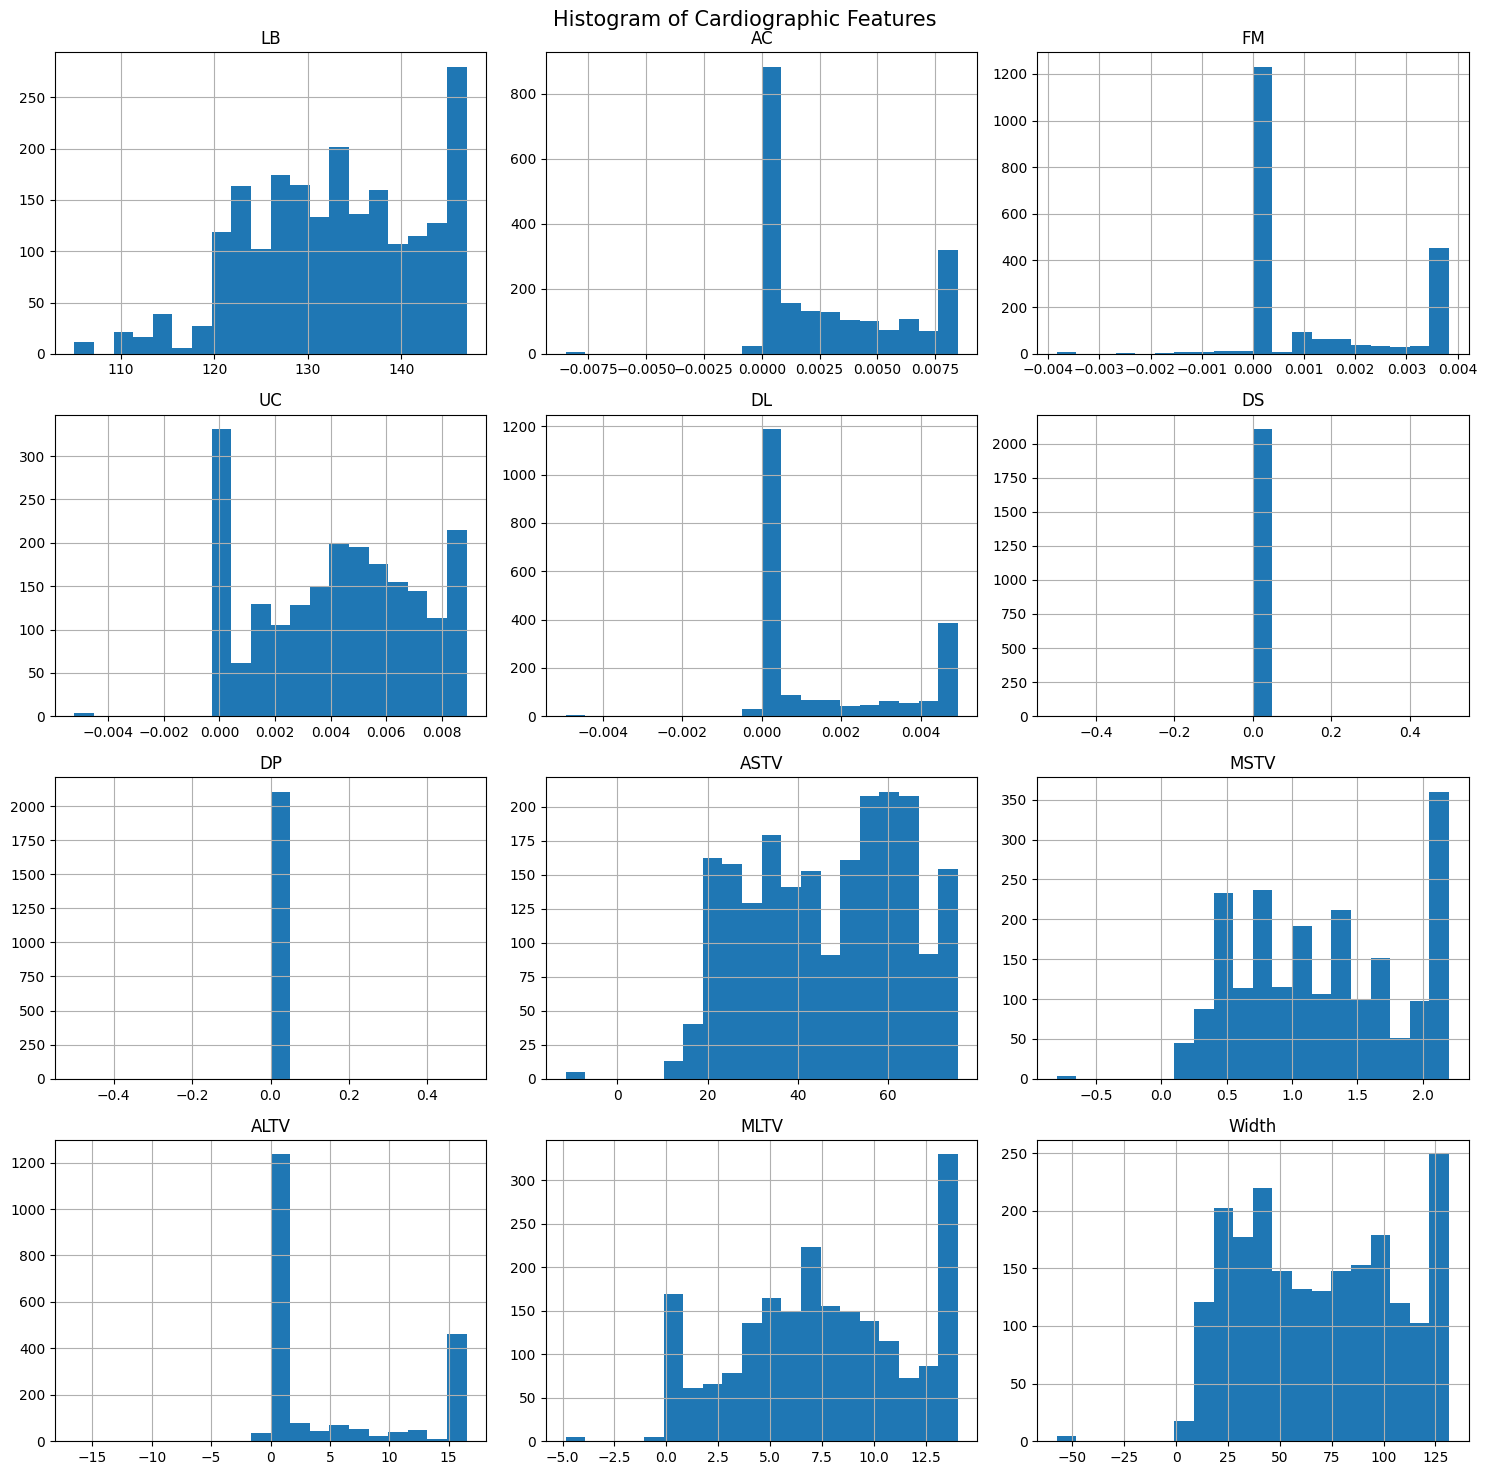

In [75]:
#histogram for numerical columns as there are many columns with value near 0 which will make the box plot look like a flat line since q3, median, q1 are near 0 values

plt.figure(figsize=(30, 30))
df[numerical_columns].hist(bins=20, figsize=(15, 15))
plt.suptitle("Histogram of Cardiographic Features", fontsize = 15)
plt.tight_layout()      #avoid over laps between plots
plt.show()

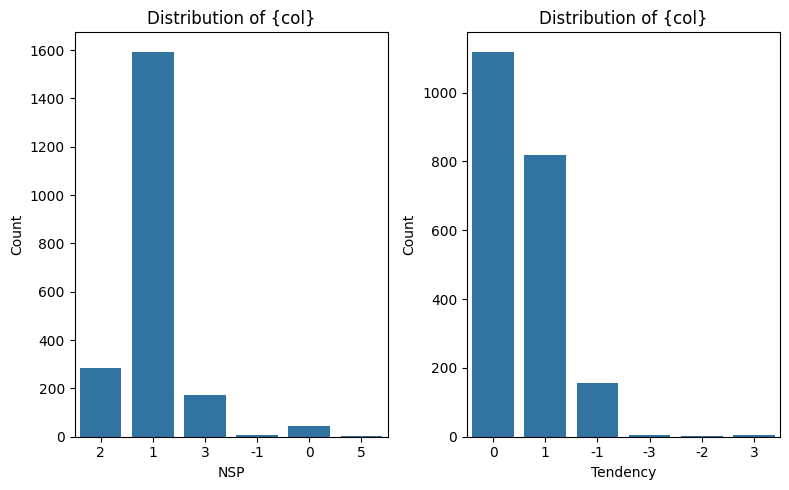

In [76]:
#bar chart for categorical columns
#converting categorical columns to string labels for seaborn to treat them as discrete categories

df['NSP'] = df['NSP'].astype(int).astype(str)
df['Tendency'] = df['Tendency'].astype(int).astype(str)

categorical_columns = ['NSP', 'Tendency']
plt.figure(figsize=(8, 5))

#loop through each categorical column
for i, col in enumerate(categorical_columns, 1):

  plt.subplot(1, 2, i)      #subplot 1 row 2 columns
  sns.countplot(x = col, data = df, width = 0.8)
  plt.title("Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")

plt.tight_layout()      #avoid overlaps between graphs
plt.show()

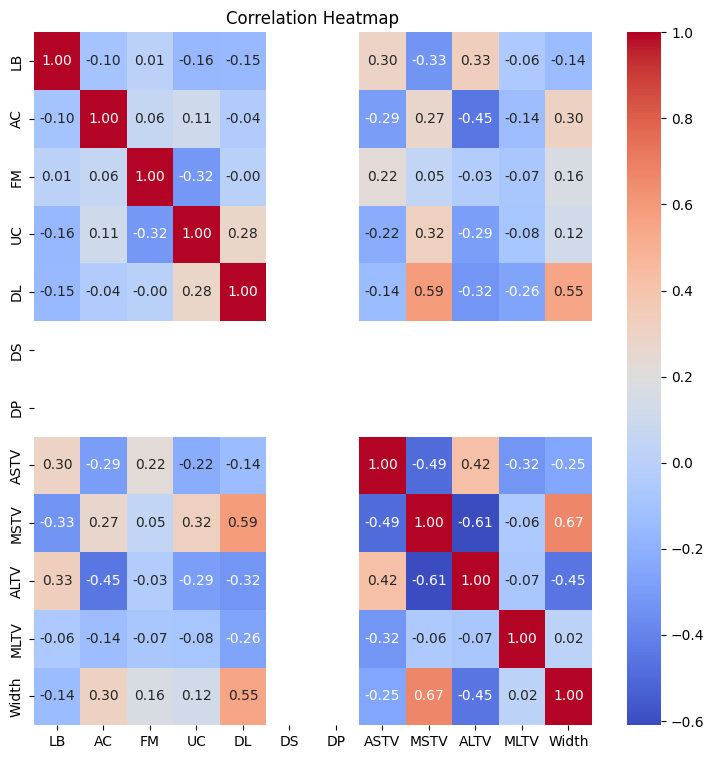


Blank areas in heatmap shows zero variance


In [79]:
#correlation heatmap
plt.figure(figsize = (9, 9))
corr = df[numerical_columns].corr()     #computes correlation for each numerical columns
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm")       #annot=True displays corr value and .2f limits values to 2 deciamal places
plt.title("Correlation Heatmap")
plt.show()
print("\nBlank areas in heatmap shows zero variance")

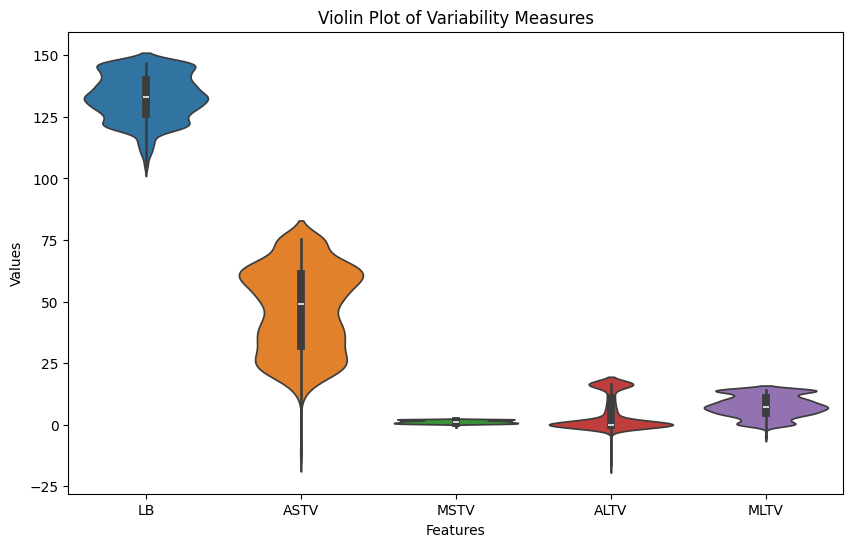

In [80]:
#violin plot shows density and spread
"""Based on heat map and histogram the optimal columns to plot violin plot are LB ASTV, MSTV, ALTV, MLTV
columns like AC, FM, UC, DL, DS, DP the values are near 0 so we will not use it as violin plot shows spread and density where values concentrate"""

violin_columns = ['LB', 'ASTV', 'MSTV', 'ALTV','MLTV']
plt.figure(figsize = (10, 6))
sns.violinplot(data = df[violin_columns])
plt.title("Violin Plot of Variability Measures")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()


### *   Pattern Recognition and Insights:





In [83]:
#correlation matrix
corr = df[numerical_columns].corr()

#extract strong correlations (exclude self-correlation)
strong_corr = (
    corr.where(corr.abs() > 0.5)        #keeeps only strong correlation
        .stack()                        #convert matrix to row wise
        .reset_index()                  #reset index to turn into df
)

#rename columns and remove self correlations
strong_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
strong_corr = strong_corr[strong_corr['Feature 1'] != strong_corr['Feature 2']]

strong_corr

,Feature 1,Feature 2,Correlation
5,DL,MSTV,0.585942
6,DL,Width,0.550431
8,MSTV,DL,0.585942
10,MSTV,ALTV,-0.609880
11,MSTV,Width,0.672289
12,ALTV,MSTV,-0.609880
15,Width,DL,0.550431
16,Width,MSTV,0.672289


In [59]:
"""The correlation analysis identified several moderate and string realtionships among features, MSTV showed a positive strong correlation with Width indicating higher
variability leads to greater dispersion in heart rates value

MSTV alsho has negative correlation with ALTV suggesting that healtier variability are associated with fewer fluctuations

DL demonstrated moderate positive correlation with both MSTV and Width which shows their influence on overall heart rate

The dataset doesnot contain temporal or time based variable like time stapms trend analysis over time cannot be performed """


'The correlation analysis identified several moderate and string realtionships among features, MSTV showed a positive strong correlation with Width indicating higher \n\nvariability leads to greater dispersion in heart rates value\n\nMSTV alsho has negative correlation with ALTV suggesting that healtier variability are associated with fewer fluctuations\n\nDL demonstrated moderate positive correlation with both MSTV and Width which shows their influence on overall heart rate\n\nThe dataset doesnot contain temporal or time based variable like time stapms trend analysis over time cannot be performed '

### *   Conclusion:


In [85]:
"""The exploratory analysis revealed MSTV, ASTV, ALTV, MLTV, Width are the most informative variables showing meaningful distribution and good correlations.
These findings suggest that variability realted features are critical and important in decision making and furhter analysis for further prediction or risk management.
The absence of temporal data limits the trend analysis as data set with time based data caould enable deeper insights"""

'The exploratory analysis revealed MSTV, ASTV, ALTV, MLTV, Width are the most informative variables showing meaningful distribution and good correlations.\nThese findings suggest that variability realted features are critical and important in decision making and furhter analysis for further prediction or risk management.\nThe absence of temporal data limits the trend analysis as data set with time based data caould enable deeper insights'